# DeformableCNN on VocalSet (paper-style training)

Реализация по мотивам статьи **Deformable CNN and Imbalance-Aware Feature Learning for Singing Technique Classification** (Interspeech 2022, arXiv:2206.12230), адаптированная под **VocalSet**:
- Метка класса: `technique`.
- Split без утечки певцов: `GroupShuffleSplit` по `singer`.
- Deformable convolution.
- Weighted CE: `w_c = 1 / n_c^α`.
- Decoupled training (`cRT`): retrain classifier with frozen feature extractor.


In [9]:
# Optional install (uncomment if needed)
# !pip install -U torch torchvision torchaudio soundfile scikit-learn pandas matplotlib seaborn tqdm

import json
import random
from dataclasses import dataclass
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchaudio
import soundfile as sf
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, f1_score
from sklearn.model_selection import GroupShuffleSplit

try:
    from torchvision.ops import DeformConv2d
    HAS_DEFORM_CONV = True
except Exception:
    HAS_DEFORM_CONV = False

print('torch:', torch.__version__)
print('torchaudio:', torchaudio.__version__)
print('deform_conv_available:', HAS_DEFORM_CONV)


torch: 2.11.0+cu130
torchaudio: 2.11.0.dev20260419+cu130
deform_conv_available: True


In [10]:
import torch
import torchvision
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)

PyTorch: 2.11.0+cu130
TorchVision: 0.27.0.dev20260419+cu130


In [11]:
# Config
SEED = 42

VOCALSET_CSV_REL = Path('data/eda_cache/vocalset_audio_v3.csv')
LABEL_COL = 'technique'
GROUP_COL = 'singer'

# VocalSet has a tiny `vibrado` typo-like class. Merge it into vibrato by default.
TECHNIQUE_ALIASES = {
    'vibrado': 'vibrato',
}

# Spoken excerpts are useful for other tasks, but they are not a singing-technique class.
# Set to [] if you want to keep every VocalSet label.
DROP_TECHNIQUES = ['spoken']

TARGET_SR = 44_100
CLIP_SEC = 3.0
CLIP_SAMPLES = int(TARGET_SR * CLIP_SEC)
KEEP_LAST_PARTIAL = True

VAL_SIZE = 0.25

DC_MODE = 'late'      # one of: none, all, early, late, last
DROPOUT = 0.3
FEATURE_DIM = 30

TRAINING_STRATEGY = 'crt_wc'  # one of: joint, crt_wfc, crt_wc
ALPHA = 0.2
STAGE1_EPOCHS = 20
STAGE2_EPOCHS = 20

BATCH_SIZE = 32
LR = 1e-4
WEIGHT_DECAY = 0.0

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_WORKERS = 2

OUTPUT_DIR_REL = Path('ZeroToHero/outputs/deformable_cnn_vocalset')


def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


seed_everything(SEED)
print('Device:', DEVICE)


Device: cuda


In [12]:
# Paths + VocalSet loading

def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for p in [start, *start.parents]:
        if (p / VOCALSET_CSV_REL).exists():
            return p
    raise FileNotFoundError(f'Could not find {VOCALSET_CSV_REL}')


def normalize_label(value):
    value = str(value).strip().lower()
    return TECHNIQUE_ALIASES.get(value, value)


def to_abs(path_value):
    p = Path(str(path_value))
    if p.is_absolute():
        return str(p)
    return str((PROJECT_ROOT / p).resolve())


PROJECT_ROOT = find_project_root()
VOCALSET_CSV = PROJECT_ROOT / VOCALSET_CSV_REL
OUTPUT_DIR = PROJECT_ROOT / OUTPUT_DIR_REL
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

raw_df = pd.read_csv(VOCALSET_CSV)
df = raw_df.copy()
df[LABEL_COL] = df[LABEL_COL].map(normalize_label)
df[GROUP_COL] = df[GROUP_COL].astype(str).str.strip().str.lower()

if DROP_TECHNIQUES:
    drop_set = {normalize_label(x) for x in DROP_TECHNIQUES}
    before = len(df)
    df = df[~df[LABEL_COL].isin(drop_set)].copy()
    print(f'Dropped techniques {sorted(drop_set)}: {before - len(df)} rows')

df['path'] = df['path'].map(to_abs)
exists = df['path'].map(lambda p: Path(p).exists())
missing = int((~exists).sum())
if missing > 0:
    print('Dropped missing files:', missing)
df = df[exists].reset_index(drop=True)

valid_labels = sorted(df[LABEL_COL].dropna().unique())
print('Prepared rows:', len(df))
print('Num classes:', len(valid_labels))
print(df[LABEL_COL].value_counts().to_string())


Dropped techniques ['spoken']: 20 rows
Prepared rows: 3593
Num classes: 16
technique
slow_piano    397
slow_forte    395
fast_forte    394
fast_piano    386
straight      361
vibrato       261
belt          205
lip_trill     202
breathy       200
vocal_fry     198
forte         100
trillo        100
inhaled       100
pp            100
messa          99
trill          95


/tmp/ipykernel_42652/3515528676.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette='viridis')
/tmp/ipykernel_42652/3515528676.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=speaker_counts.index, y=speaker_counts.values, ax=axes[1], palette='crest')
/tmp/ipykernel_42652/3515528676.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=music_counts.index, y=music_counts.values, ax=axes[2], palette='mako')


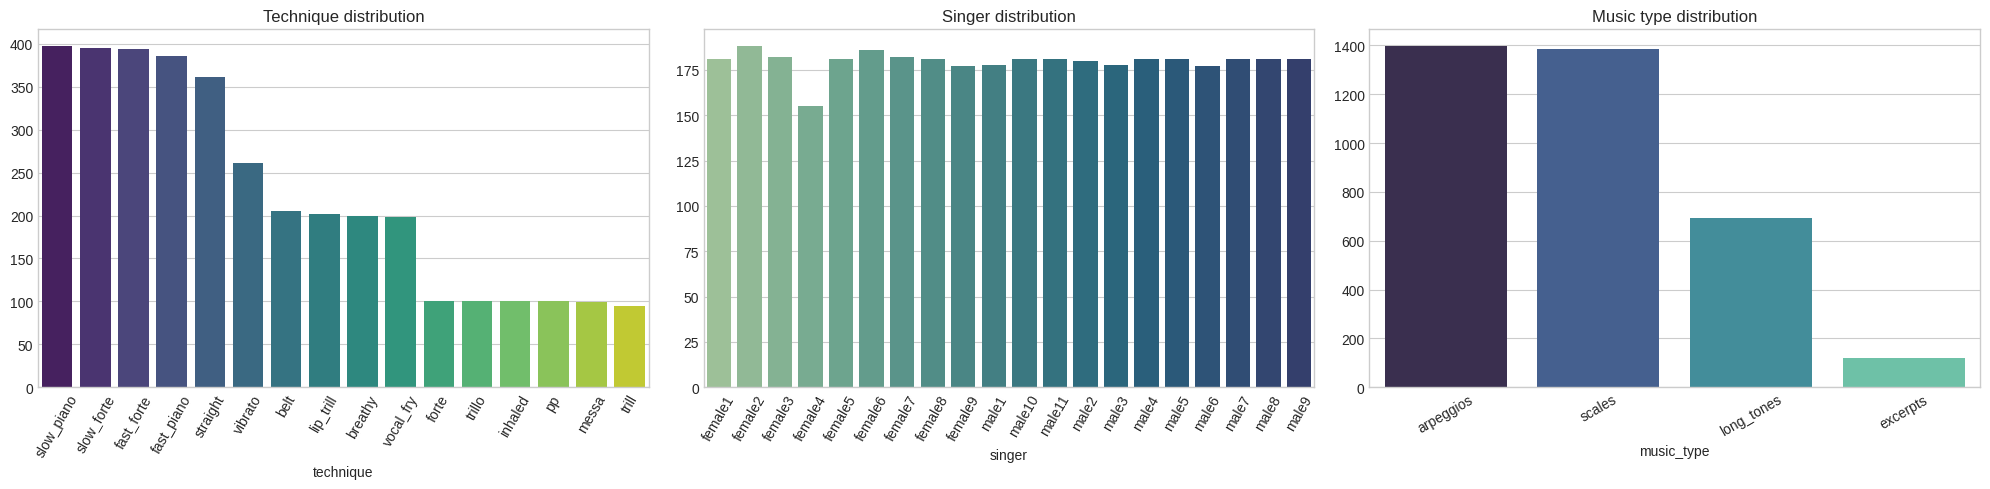

In [13]:
# Basic EDA
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

class_counts = df[LABEL_COL].value_counts().sort_values(ascending=False)
sns.barplot(x=class_counts.index, y=class_counts.values, ax=axes[0], palette='viridis')
axes[0].set_title('Technique distribution')
axes[0].tick_params(axis='x', rotation=60)

speaker_counts = df[GROUP_COL].astype(str).value_counts().sort_index()
sns.barplot(x=speaker_counts.index, y=speaker_counts.values, ax=axes[1], palette='crest')
axes[1].set_title('Singer distribution')
axes[1].tick_params(axis='x', rotation=60)

music_counts = df['music_type'].value_counts().sort_values(ascending=False)
sns.barplot(x=music_counts.index, y=music_counts.values, ax=axes[2], palette='mako')
axes[2].set_title('Music type distribution')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


In [14]:
# Build 3-second non-overlap clips + split

def estimate_samples(row):
    if pd.notna(row.get('n_frames')):
        try:
            return int(row['n_frames'])
        except Exception:
            pass
    if pd.notna(row.get('duration_sec')):
        return int(float(row['duration_sec']) * TARGET_SR)
    return None


segments = []
for _, row in df.iterrows():
    n_samples = estimate_samples(row)
    if n_samples is None or n_samples <= 0:
        continue

    starts = list(range(0, n_samples, CLIP_SAMPLES))
    if not KEEP_LAST_PARTIAL:
        starts = [s for s in starts if s + CLIP_SAMPLES <= n_samples]
    if len(starts) == 0:
        starts = [0]

    for s in starts:
        segments.append({
            'path': row['path'],
            'label': row[LABEL_COL],
            'singer': str(row[GROUP_COL]),
            'music_type': row.get('music_type'),
            'vowel': row.get('vowel'),
            'start_sample': int(s),
            'total_samples': int(n_samples),
        })

seg_df = pd.DataFrame(segments)
print('Num clips:', len(seg_df))
print(seg_df['label'].value_counts().to_string())

splitter = GroupShuffleSplit(n_splits=1, test_size=VAL_SIZE, random_state=SEED)
train_idx, val_idx = next(splitter.split(seg_df, y=seg_df['label'], groups=seg_df['singer']))
train_df = seg_df.iloc[train_idx].reset_index(drop=True)
val_df = seg_df.iloc[val_idx].reset_index(drop=True)

all_labels = set(seg_df['label'].unique())
if set(train_df['label'].unique()) != all_labels or set(val_df['label'].unique()) != all_labels:
    print('Grouped singer split dropped a class. Fallback to stratified clip split.')
    from sklearn.model_selection import train_test_split
    train_df, val_df = train_test_split(seg_df, test_size=VAL_SIZE, random_state=SEED, stratify=seg_df['label'])
    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)

labels_sorted = sorted(train_df['label'].unique())
label2id = {lbl: i for i, lbl in enumerate(labels_sorted)}
id2label = {i: lbl for lbl, i in label2id.items()}
train_df['label_id'] = train_df['label'].map(label2id).astype(int)
val_df['label_id'] = val_df['label'].map(label2id).astype(int)

print('train clips:', len(train_df), 'val clips:', len(val_df))
print('train singers:', train_df['singer'].nunique(), 'val singers:', val_df['singer'].nunique())
print('label2id:', label2id)


Num clips: 12257
label
straight      1602
slow_piano    1597
slow_forte    1507
vibrato       1323
vocal_fry      785
breathy        655
fast_piano     654
fast_forte     641
belt           628
lip_trill      578
messa          520
trill          418
pp             380
forte          376
trillo         342
inhaled        251
train clips: 9132 val clips: 3125
train singers: 15 val singers: 5
label2id: {'belt': 0, 'breathy': 1, 'fast_forte': 2, 'fast_piano': 3, 'forte': 4, 'inhaled': 5, 'lip_trill': 6, 'messa': 7, 'pp': 8, 'slow_forte': 9, 'slow_piano': 10, 'straight': 11, 'trill': 12, 'trillo': 13, 'vibrato': 14, 'vocal_fry': 15}


In [15]:
# Multi-resolution spectrogram (3 channels)
class MultiResolutionSpectrogram(nn.Module):
    def __init__(self, n_fft=2048, hop_length=512, win_lengths=(2048, 1024, 512)):
        super().__init__()
        self.specs = nn.ModuleList([
            torchaudio.transforms.Spectrogram(
                n_fft=n_fft,
                win_length=w,
                hop_length=hop_length,
                power=2.0,
                center=True,
                pad_mode='reflect',
            )
            for w in win_lengths
        ])
        self.to_db = torchaudio.transforms.AmplitudeToDB(stype='power')

    def forward(self, wav_1d):
        x = wav_1d.unsqueeze(0)
        chans = []
        for spec in self.specs:
            s = spec(x)
            s = self.to_db(s)
            s = (s - s.mean()) / (s.std() + 1e-6)
            chans.append(s.squeeze(0))
        return torch.stack(chans, dim=0)


spec_transform = MultiResolutionSpectrogram()


In [16]:
# Dataset + DataLoader

def load_audio_segment(path, start_sample, num_frames):
    try:
        audio, sr = sf.read(
            path,
            start=int(start_sample),
            frames=int(num_frames),
            dtype='float32',
            always_2d=True,
        )
        wav = torch.from_numpy(audio.T).mean(dim=0)
        return wav, int(sr)
    except Exception as sf_error:
        # Fallback for formats/backends that soundfile cannot read.
        try:
            wav, sr = torchaudio.load(path, frame_offset=int(start_sample), num_frames=int(num_frames))
            wav = wav.mean(dim=0)
            return wav, int(sr)
        except Exception as ta_error:
            raise RuntimeError(f'Could not load audio segment from {path}') from ta_error


class VocalSetClipDataset(Dataset):
    def __init__(self, meta_df, transform, clip_samples, target_sr):
        self.df = meta_df.reset_index(drop=True)
        self.transform = transform
        self.clip_samples = int(clip_samples)
        self.target_sr = int(target_sr)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        wav, sr = load_audio_segment(row['path'], row['start_sample'], self.clip_samples)

        if sr != self.target_sr:
            wav = torchaudio.functional.resample(wav, sr, self.target_sr)

        if wav.numel() < self.clip_samples:
            wav = F.pad(wav, (0, self.clip_samples - wav.numel()))
        elif wav.numel() > self.clip_samples:
            wav = wav[:self.clip_samples]

        x = self.transform(wav)
        y = torch.tensor(int(row['label_id']), dtype=torch.long)
        return x, y


train_ds = VocalSetClipDataset(train_df, spec_transform, CLIP_SAMPLES, TARGET_SR)
val_ds = VocalSetClipDataset(val_df, spec_transform, CLIP_SAMPLES, TARGET_SR)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

x0, y0 = train_ds[0]
print('Input [C,F,T]:', tuple(x0.shape), 'label:', int(y0), id2label[int(y0)])


Input [C,F,T]: (3, 1025, 259) label: 11 straight


In [17]:
# Deformable CNN (paper-inspired)
if not HAS_DEFORM_CONV:
    raise ImportError('torchvision.ops.DeformConv2d is not available. Install matching torchvision.')


def _padding_from_kernel(kernel_size):
    kh, kw = kernel_size
    return (kh // 2, kw // 2)


class ConvBlock2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, pool_size, dropout=0.3):
        super().__init__()
        pad = _padding_from_kernel(kernel_size)
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=kernel_size, padding=pad, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(pool_size)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        x = self.conv(x)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.drop(x)
        return x


class DeformConvBlock2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size, pool_size, dropout=0.3):
        super().__init__()
        pad = _padding_from_kernel(kernel_size)
        kh, kw = kernel_size
        self.offset = nn.Conv2d(in_ch, 2 * kh * kw, kernel_size=kernel_size, padding=pad)
        self.dconv = DeformConv2d(in_ch, out_ch, kernel_size=kernel_size, padding=pad, bias=False)
        self.bn = nn.BatchNorm2d(out_ch)
        self.relu = nn.ReLU(inplace=True)
        self.pool = nn.MaxPool2d(pool_size)
        self.drop = nn.Dropout(dropout)

    def forward(self, x):
        offset = self.offset(x)
        x = self.dconv(x, offset)
        x = self.bn(x)
        x = self.relu(x)
        x = self.pool(x)
        x = self.drop(x)
        return x


class DeformableOblongCNN(nn.Module):
    def __init__(self, num_classes, dc_mode='late', dropout=0.3, feature_dim=30):
        super().__init__()
        use_dc = {
            'none': [False, False, False, False],
            'all': [True, True, True, True],
            'early': [True, True, False, False],
            'late': [False, False, True, True],
            'last': [False, False, False, True],
        }[dc_mode]

        kernels = [(4, 1), (16, 1), (1, 4), (1, 16)]
        pools = [(4, 4), (4, 4), (3, 3), (2, 2)]
        channels = [3, 32, 64, 128, 128]

        blocks = []
        for i in range(4):
            cls = DeformConvBlock2d if use_dc[i] else ConvBlock2d
            blocks.append(cls(channels[i], channels[i + 1], kernels[i], pools[i], dropout=dropout))
        self.blocks = nn.ModuleList(blocks)

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc_feature = nn.Linear(128, feature_dim)
        self.fc_out = nn.Linear(feature_dim, num_classes)

    def forward_features(self, x):
        for b in self.blocks:
            x = b(x)
        x = self.global_pool(x).flatten(1)
        return self.fc_feature(x)

    def forward_classifier(self, feat):
        return self.fc_out(feat)

    def forward(self, x):
        feat = self.forward_features(x)
        return self.forward_classifier(feat)


num_classes = len(label2id)
model = DeformableOblongCNN(num_classes=num_classes, dc_mode=DC_MODE, dropout=DROPOUT, feature_dim=FEATURE_DIM).to(DEVICE)
print('Params:', f"{sum(p.numel() for p in model.parameters()):,}")


Params: 400,758


In [18]:
# Weighted loss + metric helpers

def make_class_weights_from_counts(counts, alpha, num_classes):
    w = np.ones(num_classes, dtype=np.float32)
    for c in range(num_classes):
        n = float(counts.get(c, 1.0))
        w[c] = 1.0 / (n ** float(alpha))
    w = w / (w.mean() + 1e-12)
    return torch.tensor(w, dtype=torch.float32)


train_counts = train_df['label_id'].value_counts().to_dict()
class_weights = make_class_weights_from_counts(train_counts, ALPHA, num_classes).to(DEVICE)
print('class_weights:', class_weights.detach().cpu().numpy())

criterion_plain = nn.CrossEntropyLoss()
criterion_weighted = nn.CrossEntropyLoss(weight=class_weights)


@torch.no_grad()
def eval_model(model, loader):
    model.eval()
    all_logits, all_y = [], []
    total_loss, n = 0.0, 0
    ce = nn.CrossEntropyLoss()

    for x, y in loader:
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)
        logits = model(x)
        loss = ce(logits, y)

        bs = y.size(0)
        total_loss += float(loss.item()) * bs
        n += bs

        all_logits.append(logits.detach().cpu())
        all_y.append(y.detach().cpu())

    logits = torch.cat(all_logits, dim=0)
    y_true = torch.cat(all_y, dim=0).numpy()
    probs = torch.softmax(logits, dim=1).numpy()
    y_pred = probs.argmax(axis=1)

    top2 = (np.argsort(-probs, axis=1)[:, :2] == y_true[:, None]).any(axis=1).mean()
    top3 = (np.argsort(-probs, axis=1)[:, :3] == y_true[:, None]).any(axis=1).mean()

    metrics = {
        'val_loss': total_loss / max(n, 1),
        'acc': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'balanced_acc': balanced_accuracy_score(y_true, y_pred),
        'top2_acc': float(top2),
        'top3_acc': float(top3),
    }
    return metrics, y_true, y_pred


def run_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, n = 0.0, 0
    for x, y in tqdm(loader, leave=False):
        x = x.to(DEVICE, non_blocking=True)
        y = y.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += float(loss.item()) * bs
        n += bs

    return total_loss / max(n, 1)


class_weights: [0.99239933 0.9848015  1.000363   0.99321985 1.1068622  1.2086459
 1.0114563  1.051607   1.1045138  0.8375077  0.8250717  0.82574904
 1.1029646  1.1233283  0.8616365  0.96987337]


In [20]:
# Training strategy: joint / cRT-WFC / cRT-WC

def set_requires_grad(module, flag):
    for p in module.parameters():
        p.requires_grad = flag


def train_with_strategy(model, strategy='crt_wc'):
    assert strategy in {'joint', 'crt_wfc', 'crt_wc'}

    history = []
    best = {'macro_f1': -1.0, 'state': None}

    if strategy in {'joint', 'crt_wfc'}:
        criterion_stage1 = criterion_weighted
    else:
        criterion_stage1 = criterion_plain

    opt1 = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    print(f"\n[Stage 1] {strategy}, epochs={STAGE1_EPOCHS}")

    for epoch in range(1, STAGE1_EPOCHS + 1):
        tr_loss = run_epoch(model, train_loader, opt1, criterion_stage1)
        metrics, _, _ = eval_model(model, val_loader)
        history.append({'stage': 1, 'epoch': epoch, 'train_loss': tr_loss, **metrics})

        if metrics['macro_f1'] > best['macro_f1']:
            best = {'macro_f1': metrics['macro_f1'], 'state': {k: v.cpu() for k, v in model.state_dict().items()}}

        print(f"S1 E{epoch:03d} | loss={tr_loss:.4f} | f1={metrics['macro_f1']:.4f} | acc={metrics['acc']:.4f}")

    if strategy in {'crt_wfc', 'crt_wc'} and STAGE2_EPOCHS > 0:
        print(f"\n[Stage 2 cRT] epochs={STAGE2_EPOCHS}")
        set_requires_grad(model.blocks, False)
        set_requires_grad(model.global_pool, False)
        set_requires_grad(model.fc_feature, False)
        set_requires_grad(model.fc_out, True)

        opt2 = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR, weight_decay=WEIGHT_DECAY)

        for epoch in range(1, STAGE2_EPOCHS + 1):
            tr_loss = run_epoch(model, train_loader, opt2, criterion_weighted)
            metrics, _, _ = eval_model(model, val_loader)
            history.append({'stage': 2, 'epoch': epoch, 'train_loss': tr_loss, **metrics})

            if metrics['macro_f1'] > best['macro_f1']:
                best = {'macro_f1': metrics['macro_f1'], 'state': {k: v.cpu() for k, v in model.state_dict().items()}}

            print(f"S2 E{epoch:03d} | loss={tr_loss:.4f} | f1={metrics['macro_f1']:.4f} | acc={metrics['acc']:.4f}")

    if best['state'] is not None:
        model.load_state_dict(best['state'])

    return model, pd.DataFrame(history)


model, hist_df = train_with_strategy(model, strategy=TRAINING_STRATEGY)
hist_df.to_csv(OUTPUT_DIR / 'training_history.csv', index=False)
print('Saved training history:', OUTPUT_DIR / 'training_history.csv')



[Stage 1] crt_wc, epochs=20


  0%|          | 0/286 [00:00<?, ?it/s]

S1 E001 | loss=2.1136 | f1=0.0679 | acc=0.1786


  0%|          | 0/286 [00:00<?, ?it/s]

S1 E002 | loss=1.9947 | f1=0.0782 | acc=0.1904


...

S1 E009 | loss=1.6029 | f1=0.1382 | acc=0.1875


  0%|          | 0/286 [00:00<?, ?it/s]

S1 E010 | loss=1.5733 | f1=0.1174 | acc=0.1766


  0%|          | 0/286 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
# Final evaluation + save artifacts
final_metrics, y_true, y_pred = eval_model(model, val_loader)
print(json.dumps(final_metrics, indent=2))

ordered_ids = sorted(id2label.keys())
ordered_labels = [id2label[i] for i in ordered_ids]

report = classification_report(y_true, y_pred, labels=ordered_ids, target_names=ordered_labels, output_dict=True, zero_division=0)
report_df = pd.DataFrame(report).T
cm = confusion_matrix(y_true, y_pred, labels=ordered_ids)
cm_df = pd.DataFrame(cm, index=ordered_labels, columns=ordered_labels)

display(report_df)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.lineplot(data=hist_df, x=np.arange(len(hist_df)), y='macro_f1', ax=axes[0])
axes[0].set_title('Validation Macro-F1 over epochs')
axes[0].set_xlabel('epoch index')
axes[0].set_ylabel('macro_f1')

sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=axes[1])
axes[1].set_title('Validation confusion matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('True')
plt.tight_layout()
plt.show()

artifact = {
    'config': {
        'dc_mode': DC_MODE,
        'training_strategy': TRAINING_STRATEGY,
        'alpha': ALPHA,
        'stage1_epochs': STAGE1_EPOCHS,
        'stage2_epochs': STAGE2_EPOCHS,
        'batch_size': BATCH_SIZE,
        'lr': LR,
        'drop_techniques': DROP_TECHNIQUES,
        'technique_aliases': TECHNIQUE_ALIASES,
        'clip_sec': CLIP_SEC,
        'target_sr': TARGET_SR,
    },
    'metrics': final_metrics,
    'label2id': label2id,
}

with open(OUTPUT_DIR / 'val_metrics.json', 'w', encoding='utf-8') as f:
    json.dump(artifact, f, indent=2, ensure_ascii=False)
report_df.to_csv(OUTPUT_DIR / 'val_classification_report.csv')
cm_df.to_csv(OUTPUT_DIR / 'val_confusion_matrix.csv')
torch.save(model.state_dict(), OUTPUT_DIR / 'deformable_cnn_vocalset.pt')

print('Saved artifacts to:', OUTPUT_DIR)


## Notes
- В статье лучший сетап: `DC_MODE='late'` и `TRAINING_STRATEGY='crt_wc'` с `ALPHA=0.2`.
- Для более точного воспроизведения статьи увеличьте эпохи (например 100 + 100) и `BATCH_SIZE=64` при достаточной памяти.
- Если нужен strict singer-independent validation, оставьте grouped split. Если важнее сохранить все классы в validation при редких техниках, fallback автоматически переключится на stratified clip split.
- Чтобы обучать на всех VocalSet записях без исключений, установите `DROP_TECHNIQUES = []`.
